In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/server")
LOGS_DIR = RESULTS_DIR / "dsb_dense_logs"

seeds = [42, 43, 44, 45, 46]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(seeds)))

training_logs = {}
for seed in seeds:
    log_path = LOGS_DIR / f"seed{seed}_info.json"
    if not log_path.exists():
        print(f"seed={seed}: not found at {log_path}")
        continue
    with open(log_path) as f:
        training_logs[seed] = json.load(f)
    print(f"seed={seed}: {len(training_logs[seed])} epoch records loaded")

seed=42: 200 epoch records loaded
seed=43: 200 epoch records loaded
seed=44: 200 epoch records loaded
seed=45: 200 epoch records loaded
seed=46: 200 epoch records loaded


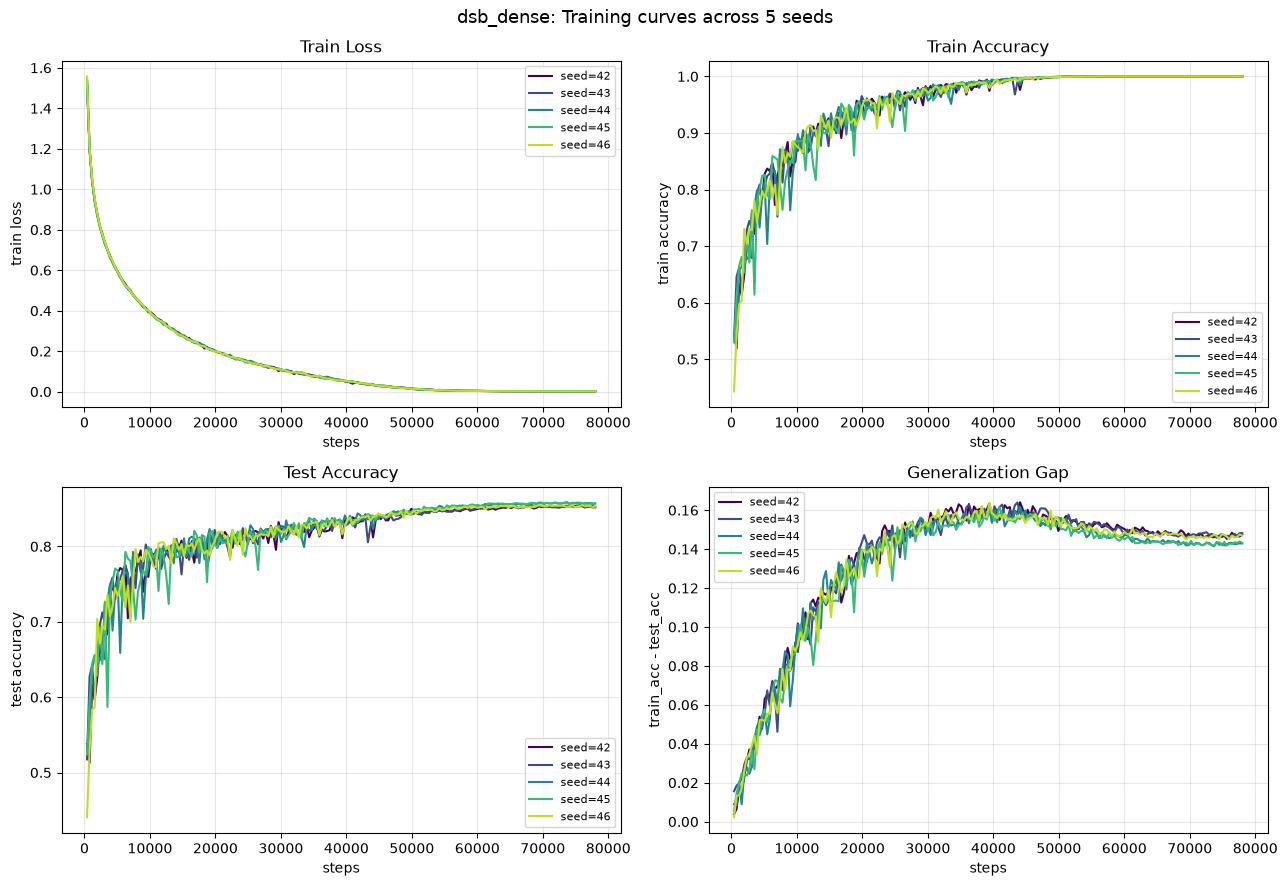

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for seed, color in zip(seeds, colors):
    if seed not in training_logs:
        continue
    log = training_logs[seed]
    steps      = [r["step"] for r in log]
    train_loss = [r["train_loss"] for r in log]
    train_acc  = [r["train_acc"] for r in log]
    test_acc   = [r["test_acc"] for r in log]

    axes[0, 0].plot(steps, train_loss, color=color, label=f"seed={seed}")
    axes[0, 1].plot(steps, train_acc,  color=color, label=f"seed={seed}")
    axes[1, 0].plot(steps, test_acc,   color=color, label=f"seed={seed}")

    gap = [ta - va for ta, va in zip(train_acc, test_acc)]
    axes[1, 1].plot(steps, gap, color=color, label=f"seed={seed}")

for ax in axes.flat:
    #ax.set_xscale("log")
    ax.set_xlabel("steps")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0, 0].set_ylabel("train loss");     axes[0, 0].set_title("Train Loss")
axes[0, 1].set_ylabel("train accuracy"); axes[0, 1].set_title("Train Accuracy")
axes[1, 0].set_ylabel("test accuracy");  axes[1, 0].set_title("Test Accuracy")
axes[1, 1].set_ylabel("train_acc - test_acc"); axes[1, 1].set_title("Generalization Gap")

fig.suptitle("dsb_dense: Training curves across 5 seeds", fontsize=13)
fig.tight_layout()
#plt.savefig(RESULTS_DIR / "dsb_dense_training_curves_5seeds.pdf", bbox_inches="tight")
plt.show()

# Calibration Check

In [17]:
import json
import numpy as np
from pathlib import Path

FINE_DIR = Path("/home/nakano/server/calibration_results_dense_fine")

seeds = [42, 43, 44, 45, 46]
steps = [1, 100, 1006, 10075, 30632, 78000]
epsilons = [3e-9, 4e-9, 5e-9, 6e-9, 7e-9, 8e-9, 1e-8]

summary = {}  # {(seed, step): {epsilon: mean_accept_prob}}

for eps in epsilons:
    eps_str = f"eps_{eps:.0e}".replace("e-0", "e-")
    eps_dir = FINE_DIR / eps_str
    if not eps_dir.exists():
        print(f"WARNING: {eps_dir} does not exist")
        continue
    for seed in seeds:
        for step in steps:
            f = eps_dir / f"calib_dense_seed{seed}_step{step}.json"
            if not f.exists():
                print(f"MISSING: {f}")
                continue
            with open(f) as fp:
                d = json.load(fp)
            for r in d["results"]:
                key = (seed, step)
                summary.setdefault(key, {})[r["epsilon"]] = r["mean_accept_prob"]

print(f"\nLoaded {len(summary)} (seed, step) combinations")


Loaded 30 (seed, step) combinations


In [18]:
# 表形式で表示
print(f"{'seed':>6} {'step':>8}", end="")
for eps in epsilons:
    print(f" {eps:>10.1e}", end="")
print()

for seed in seeds:
    for step in steps:
        key = (seed, step)
        if key not in summary:
            continue
        print(f"{seed:>6} {step:>8}", end="")
        for eps in epsilons:
            val = summary[key].get(eps, float("nan"))
            marker = "*" if 0.9 <= val <= 0.95 else " "
            print(f" {val:>9.3f}{marker}", end="")
        print()

  seed     step    3.0e-09    4.0e-09    5.0e-09    6.0e-09    7.0e-09    8.0e-09    1.0e-08
    42        1     0.897      0.893      0.868      0.856      0.905*     0.902*     0.890 
    42      100     0.882      0.899      0.886      0.875      0.889      0.904*     0.869 
    42     1006     0.861      0.883      0.881      0.870      0.891      0.880      0.879 
    42    10075     0.887      0.854      0.892      0.838      0.886      0.884      0.875 
    42    30632     0.898      0.881      0.890      0.886      0.885      0.901*     0.875 
    42    78000     0.944*     0.923*     0.912*     0.912*     0.931*     0.909*     0.890 
    43        1     0.889      0.889      0.862      0.845      0.900      0.899      0.862 
    43      100     0.855      0.906*     0.875      0.863      0.884      0.889      0.876 
    43     1006     0.891      0.890      0.903*     0.849      0.860      0.876      0.890 
    43    10075     0.873      0.873      0.871      0.872      0.868 

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FINE_DIR = Path("/home/nakano/server/calibration_results_dense_fine")

seeds = [42, 43, 44, 45, 46]
steps = [1, 100, 1006, 10075, 30632, 78000]
epsilons = [3e-9, 4e-9, 5e-9, 6e-9, 7e-9, 8e-9, 1e-8]

summary = {}  # {(seed, step): {epsilon: mean_accept_prob}}

for eps in epsilons:
    eps_str = f"eps_{eps:.0e}".replace("e-0", "e-")
    eps_dir = FINE_DIR / eps_str
    for seed in seeds:
        for step in steps:
            f = eps_dir / f"calib_dense_seed{seed}_step{step}.json"
            if not f.exists():
                continue
            with open(f) as fp:
                d = json.load(fp)
            for r in d["results"]:
                key = (seed, step)
                summary.setdefault(key, {})[r["epsilon"]] = r["mean_accept_prob"]

print(f"Loaded {len(summary)} (seed, step) combinations")

Loaded 30 (seed, step) combinations


In [20]:
print(f"{'epsilon':>10} {'n_in_range':>12} {'mean_accept':>13} {'mean_|dev_from_0.925|':>22}")
print("-" * 60)

eps_stats = {}
for eps in epsilons:
    vals = [summary[k][eps] for k in summary if eps in summary[k]]
    n_in_range = sum(1 for v in vals if 0.9 <= v <= 0.95)
    mean_accept = np.mean(vals)
    mean_dev = np.mean([abs(v - 0.925) for v in vals])  # 目標範囲の中心(0.925)からのズレ
    eps_stats[eps] = {"n_in_range": n_in_range, "mean_accept": mean_accept, "mean_dev": mean_dev, "vals": vals}
    print(f"{eps:>10.1e} {n_in_range:>12d} {mean_accept:>13.4f} {mean_dev:>22.4f}")

   epsilon   n_in_range   mean_accept  mean_|dev_from_0.925|
------------------------------------------------------------
   3.0e-09            6        0.8889                 0.0397
   4.0e-09           10        0.8963                 0.0294
   5.0e-09            6        0.8839                 0.0411
   6.0e-09            3        0.8734                 0.0516
   7.0e-09            7        0.8891                 0.0363
   8.0e-09           15        0.8967                 0.0283
   1.0e-08            2        0.8815                 0.0435


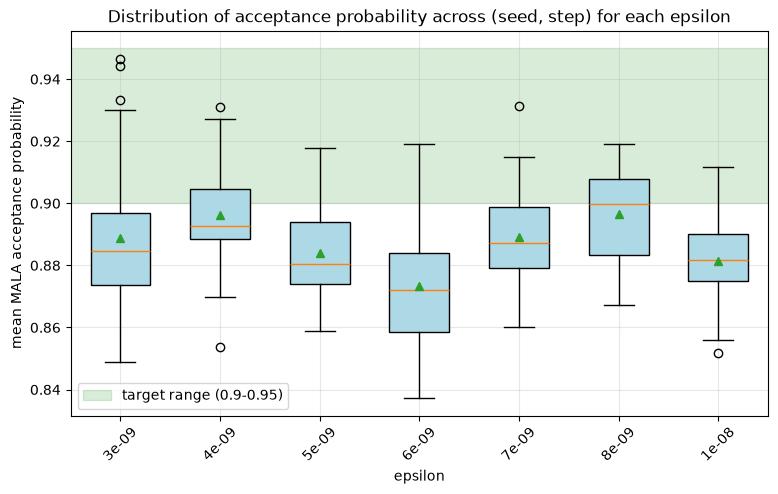

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

data_for_box = [eps_stats[eps]["vals"] for eps in epsilons]
positions = range(len(epsilons))

bp = ax.boxplot(data_for_box, positions=positions, widths=0.6,
                 patch_artist=True, showmeans=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")

ax.axhspan(0.9, 0.95, color="green", alpha=0.15, label="target range (0.9-0.95)")
ax.set_xticks(positions)
ax.set_xticklabels([f"{eps:.0e}" for eps in epsilons], rotation=45)
ax.set_xlabel("epsilon")
ax.set_ylabel("mean MALA acceptance probability")
ax.set_title("Distribution of acceptance probability across (seed, step) for each epsilon")
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(FINE_DIR.parent / "calibration_fine_boxplot.pdf", bbox_inches="tight")
plt.show()

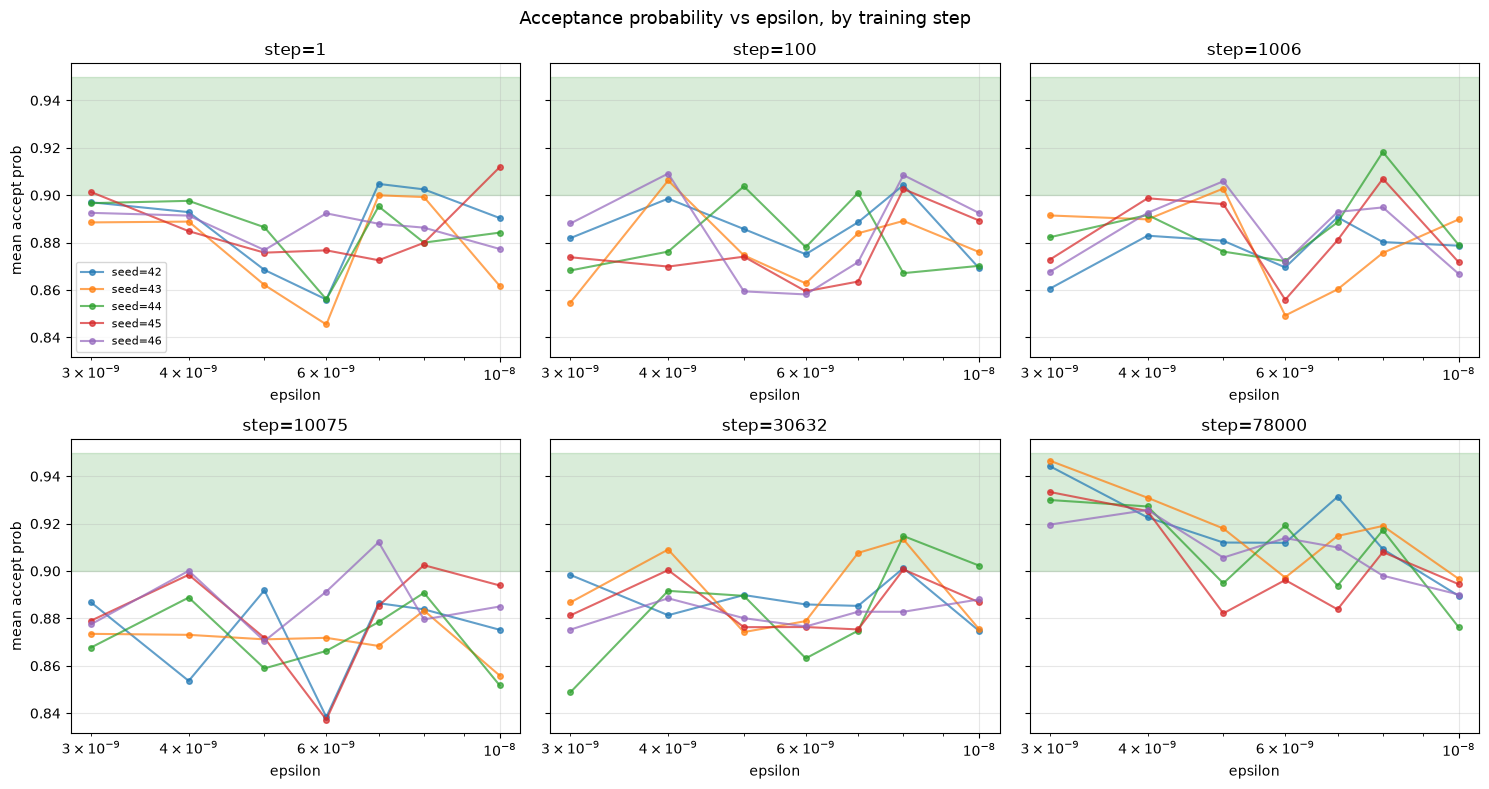

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, step in zip(axes, steps):
    for seed in seeds:
        key = (seed, step)
        if key not in summary:
            continue
        vals = [summary[key].get(eps, np.nan) for eps in epsilons]
        ax.plot(epsilons, vals, marker="o", markersize=4, alpha=0.7, label=f"seed={seed}")

    ax.axhspan(0.9, 0.95, color="green", alpha=0.15)
    ax.set_xscale("log")
    ax.set_title(f"step={step}")
    ax.set_xlabel("epsilon")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("mean accept prob")
axes[3].set_ylabel("mean accept prob")
axes[0].legend(fontsize=8, loc="lower left")

fig.suptitle("Acceptance probability vs epsilon, by training step", fontsize=13)
fig.tight_layout()
plt.savefig(FINE_DIR.parent / "calibration_fine_by_step.pdf", bbox_inches="tight")
plt.show()

In [23]:
best_eps = max(epsilons, key=lambda e: eps_stats[e]["n_in_range"])
print(f"\n最も多くの(seed, step)で目標範囲(0.9-0.95)を達成したepsilon: {best_eps:.1e}")
print(f"  達成数: {eps_stats[best_eps]['n_in_range']} / {len(summary)}")
print(f"  平均受理確率: {eps_stats[best_eps]['mean_accept']:.4f}")

# 目標中心(0.925)に最も近い平均を持つepsilon
best_eps_by_center = min(epsilons, key=lambda e: eps_stats[e]["mean_dev"])
print(f"\n目標中心(0.925)に最も平均が近いepsilon: {best_eps_by_center:.1e}")
print(f"  平均ズレ: {eps_stats[best_eps_by_center]['mean_dev']:.4f}")


最も多くの(seed, step)で目標範囲(0.9-0.95)を達成したepsilon: 8.0e-09
  達成数: 15 / 30
  平均受理確率: 0.8967

目標中心(0.925)に最も平均が近いepsilon: 8.0e-09
  平均ズレ: 0.0283


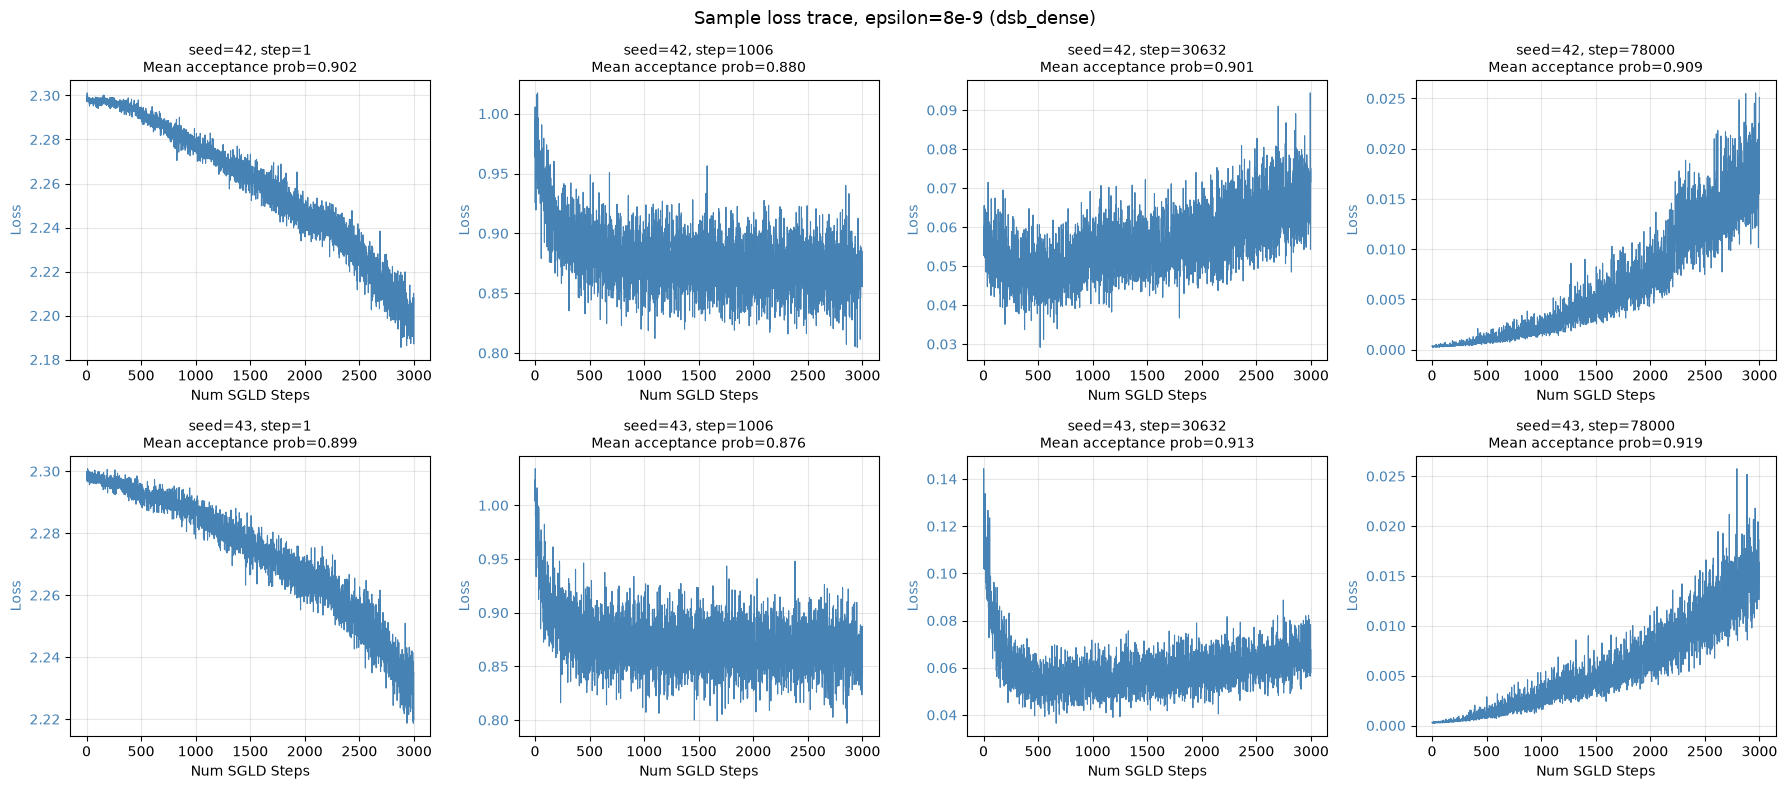

In [24]:
"""
plot_calibration_paper_style.py

論文 Figure H.1 のスタイルで、loss trace(左軸)と
MALA acceptance probability(右軸)を重ねてプロットする。

注意: 現状のJSONには acceptance_probs の生データ([t, prob]ペア)は
保存されておらず、mean_accept_prob(スカラー)のみが保存されている。
そのため、論文と全く同じ形式(受理確率の時系列)を再現するには、
acceptance_probs_raw も保存するようスクリプトを修正し、再実行する
必要がある可能性がある。
"""
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FINE_DIR = Path("/home/nakano/server/calibration_results_dense_fine/eps_8e-9")

# 代表的な例をいくつか選んで表示
seeds_to_plot = [42, 43]
steps_to_plot = [1, 1006, 30632, 78000]

fig, axes = plt.subplots(len(seeds_to_plot), len(steps_to_plot),
                          figsize=(4.5 * len(steps_to_plot), 4 * len(seeds_to_plot)))

for row, seed in enumerate(seeds_to_plot):
    for col, step in enumerate(steps_to_plot):
        ax = axes[row, col] if len(seeds_to_plot) > 1 else axes[col]

        f = FINE_DIR / f"calib_dense_seed{seed}_step{step}.json"
        if not f.exists():
            ax.set_title(f"seed={seed}, step={step}\n(not found)")
            continue

        with open(f) as fp:
            d = json.load(fp)

        r = d["results"][0]  # epsilon=8e-9は1候補のみのはず
        trace = np.array(r["loss_trace"])
        accept = r["mean_accept_prob"]

        ax.plot(trace, color="steelblue", linewidth=0.8)
        ax.set_title(f"seed={seed}, step={step}\nMean acceptance prob={accept:.3f}",
                     fontsize=10)
        ax.set_xlabel("Num SGLD Steps")
        ax.set_ylabel("Loss", color="steelblue")
        ax.tick_params(axis="y", labelcolor="steelblue")
        ax.grid(alpha=0.3)

fig.suptitle(f"Sample loss trace, epsilon=8e-9 (dsb_dense)", fontsize=13)
fig.tight_layout()
#plt.savefig(FINE_DIR.parent.parent / "calibration_loss_trace_paper_style.pdf", bbox_inches="tight")
plt.show()

In [25]:
"""
全キャリブレーション結果のloss traceを一括プロットし、
「平坦化しているか」を系統的に確認する。
"""
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FINE_DIR = Path("/home/nakano/server/calibration_results_dense_fine")
COARSE_DIR = Path("/home/nakano/server/calibration_results_dense")  # 最初の粗い探索(9候補)結果

seeds = [42, 43, 44, 45, 46]
steps = [1, 100, 1006, 10075, 30632, 78000]
epsilons_fine = [3e-9, 4e-9, 5e-9, 6e-9, 7e-9, 8e-9, 1e-8]

def flatness_score(trace, tail_frac=0.1):
    """
    burn-in後(最後のtail_frac)の傾きを見て、平坦性を数値化する。
    後半のtrace値に対して線形回帰の傾きを計算し、平坦なら0に近い値。
    """
    trace = np.array(trace)
    valid = trace[~np.isnan(trace) & ~np.isinf(trace)]
    if len(valid) < 10:
        return np.nan
    n_tail = max(int(len(valid) * tail_frac), 10)
    tail = valid[-n_tail:]
    x = np.arange(len(tail))
    slope = np.polyfit(x, tail, 1)[0]
    # 傾きをtailの平均値でスケールして相対的な傾きにする
    scale = np.mean(np.abs(tail)) + 1e-8
    return slope / scale


# 全データを走査して平坦性スコアを集計
records = []
for eps in epsilons_fine:
    eps_str = f"eps_{eps:.0e}".replace("e-0", "e-")
    eps_dir = FINE_DIR / eps_str
    for seed in seeds:
        for step in steps:
            f = eps_dir / f"calib_dense_seed{seed}_step{step}.json"
            if not f.exists():
                continue
            with open(f) as fp:
                d = json.load(fp)
            for r in d["results"]:
                score = flatness_score(r["loss_trace"])
                records.append({
                    "seed": seed, "step": step, "epsilon": eps,
                    "accept_prob": r["mean_accept_prob"],
                    "flatness_score": score,
                })

print(f"Total records: {len(records)}")

Total records: 210


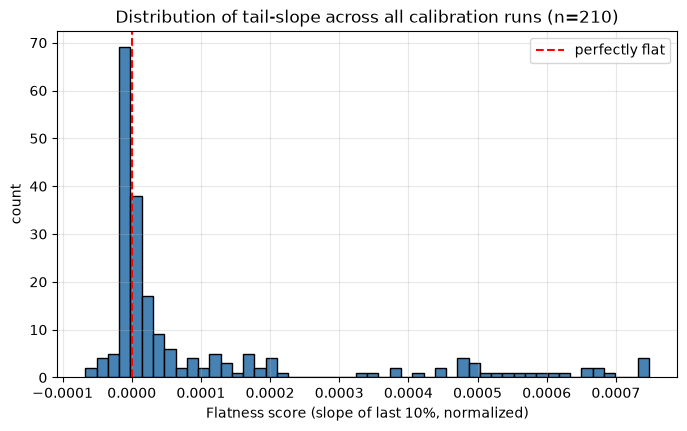

median flatness score: 0.0000
fraction with |score| > 0.001 (likely not flat): 0.00%


In [26]:
# 平坦性スコアの分布を確認(0に近いほど平坦、正なら上昇トレンド、負なら下降トレンド)
scores = [r["flatness_score"] for r in records if not np.isnan(r["flatness_score"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(scores, bins=50, color="steelblue", edgecolor="black")
ax.axvline(0, color="red", linestyle="--", label="perfectly flat")
ax.set_xlabel("Flatness score (slope of last 10%, normalized)")
ax.set_ylabel("count")
ax.set_title(f"Distribution of tail-slope across all calibration runs (n={len(scores)})")
ax.legend()
ax.grid(alpha=0.3)
plt.savefig(FINE_DIR.parent / "flatness_score_distribution.pdf", bbox_inches="tight")
plt.show()

print(f"median flatness score: {np.median(scores):.4f}")
print(f"fraction with |score| > 0.001 (likely not flat): {np.mean(np.abs(np.array(scores)) > 0.001):.2%}")

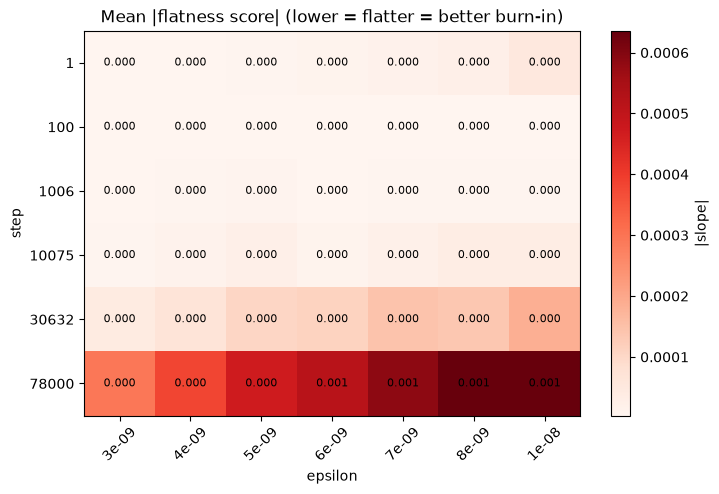

In [27]:
# step別・epsilon別に平坦性の傾向をヒートマップで見る
matrix = np.full((len(steps), len(epsilons_fine)), np.nan)
for i, step in enumerate(steps):
    for j, eps in enumerate(epsilons_fine):
        vals = [r["flatness_score"] for r in records if r["step"] == step and r["epsilon"] == eps and not np.isnan(r["flatness_score"])]
        if vals:
            matrix[i, j] = np.mean(np.abs(vals))  # 絶対値の平均(平坦からのズレの大きさ)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(matrix, aspect="auto", cmap="Reds")
for i in range(len(steps)):
    for j in range(len(epsilons_fine)):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f"{matrix[i,j]:.3f}", ha="center", va="center", fontsize=8)

ax.set_xticks(range(len(epsilons_fine)))
ax.set_xticklabels([f"{e:.0e}" for e in epsilons_fine], rotation=45)
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps)
ax.set_xlabel("epsilon")
ax.set_ylabel("step")
ax.set_title("Mean |flatness score| (lower = flatter = better burn-in)")
fig.colorbar(im, ax=ax, label="|slope|")
plt.savefig(FINE_DIR.parent / "flatness_heatmap.pdf", bbox_inches="tight")
plt.show()

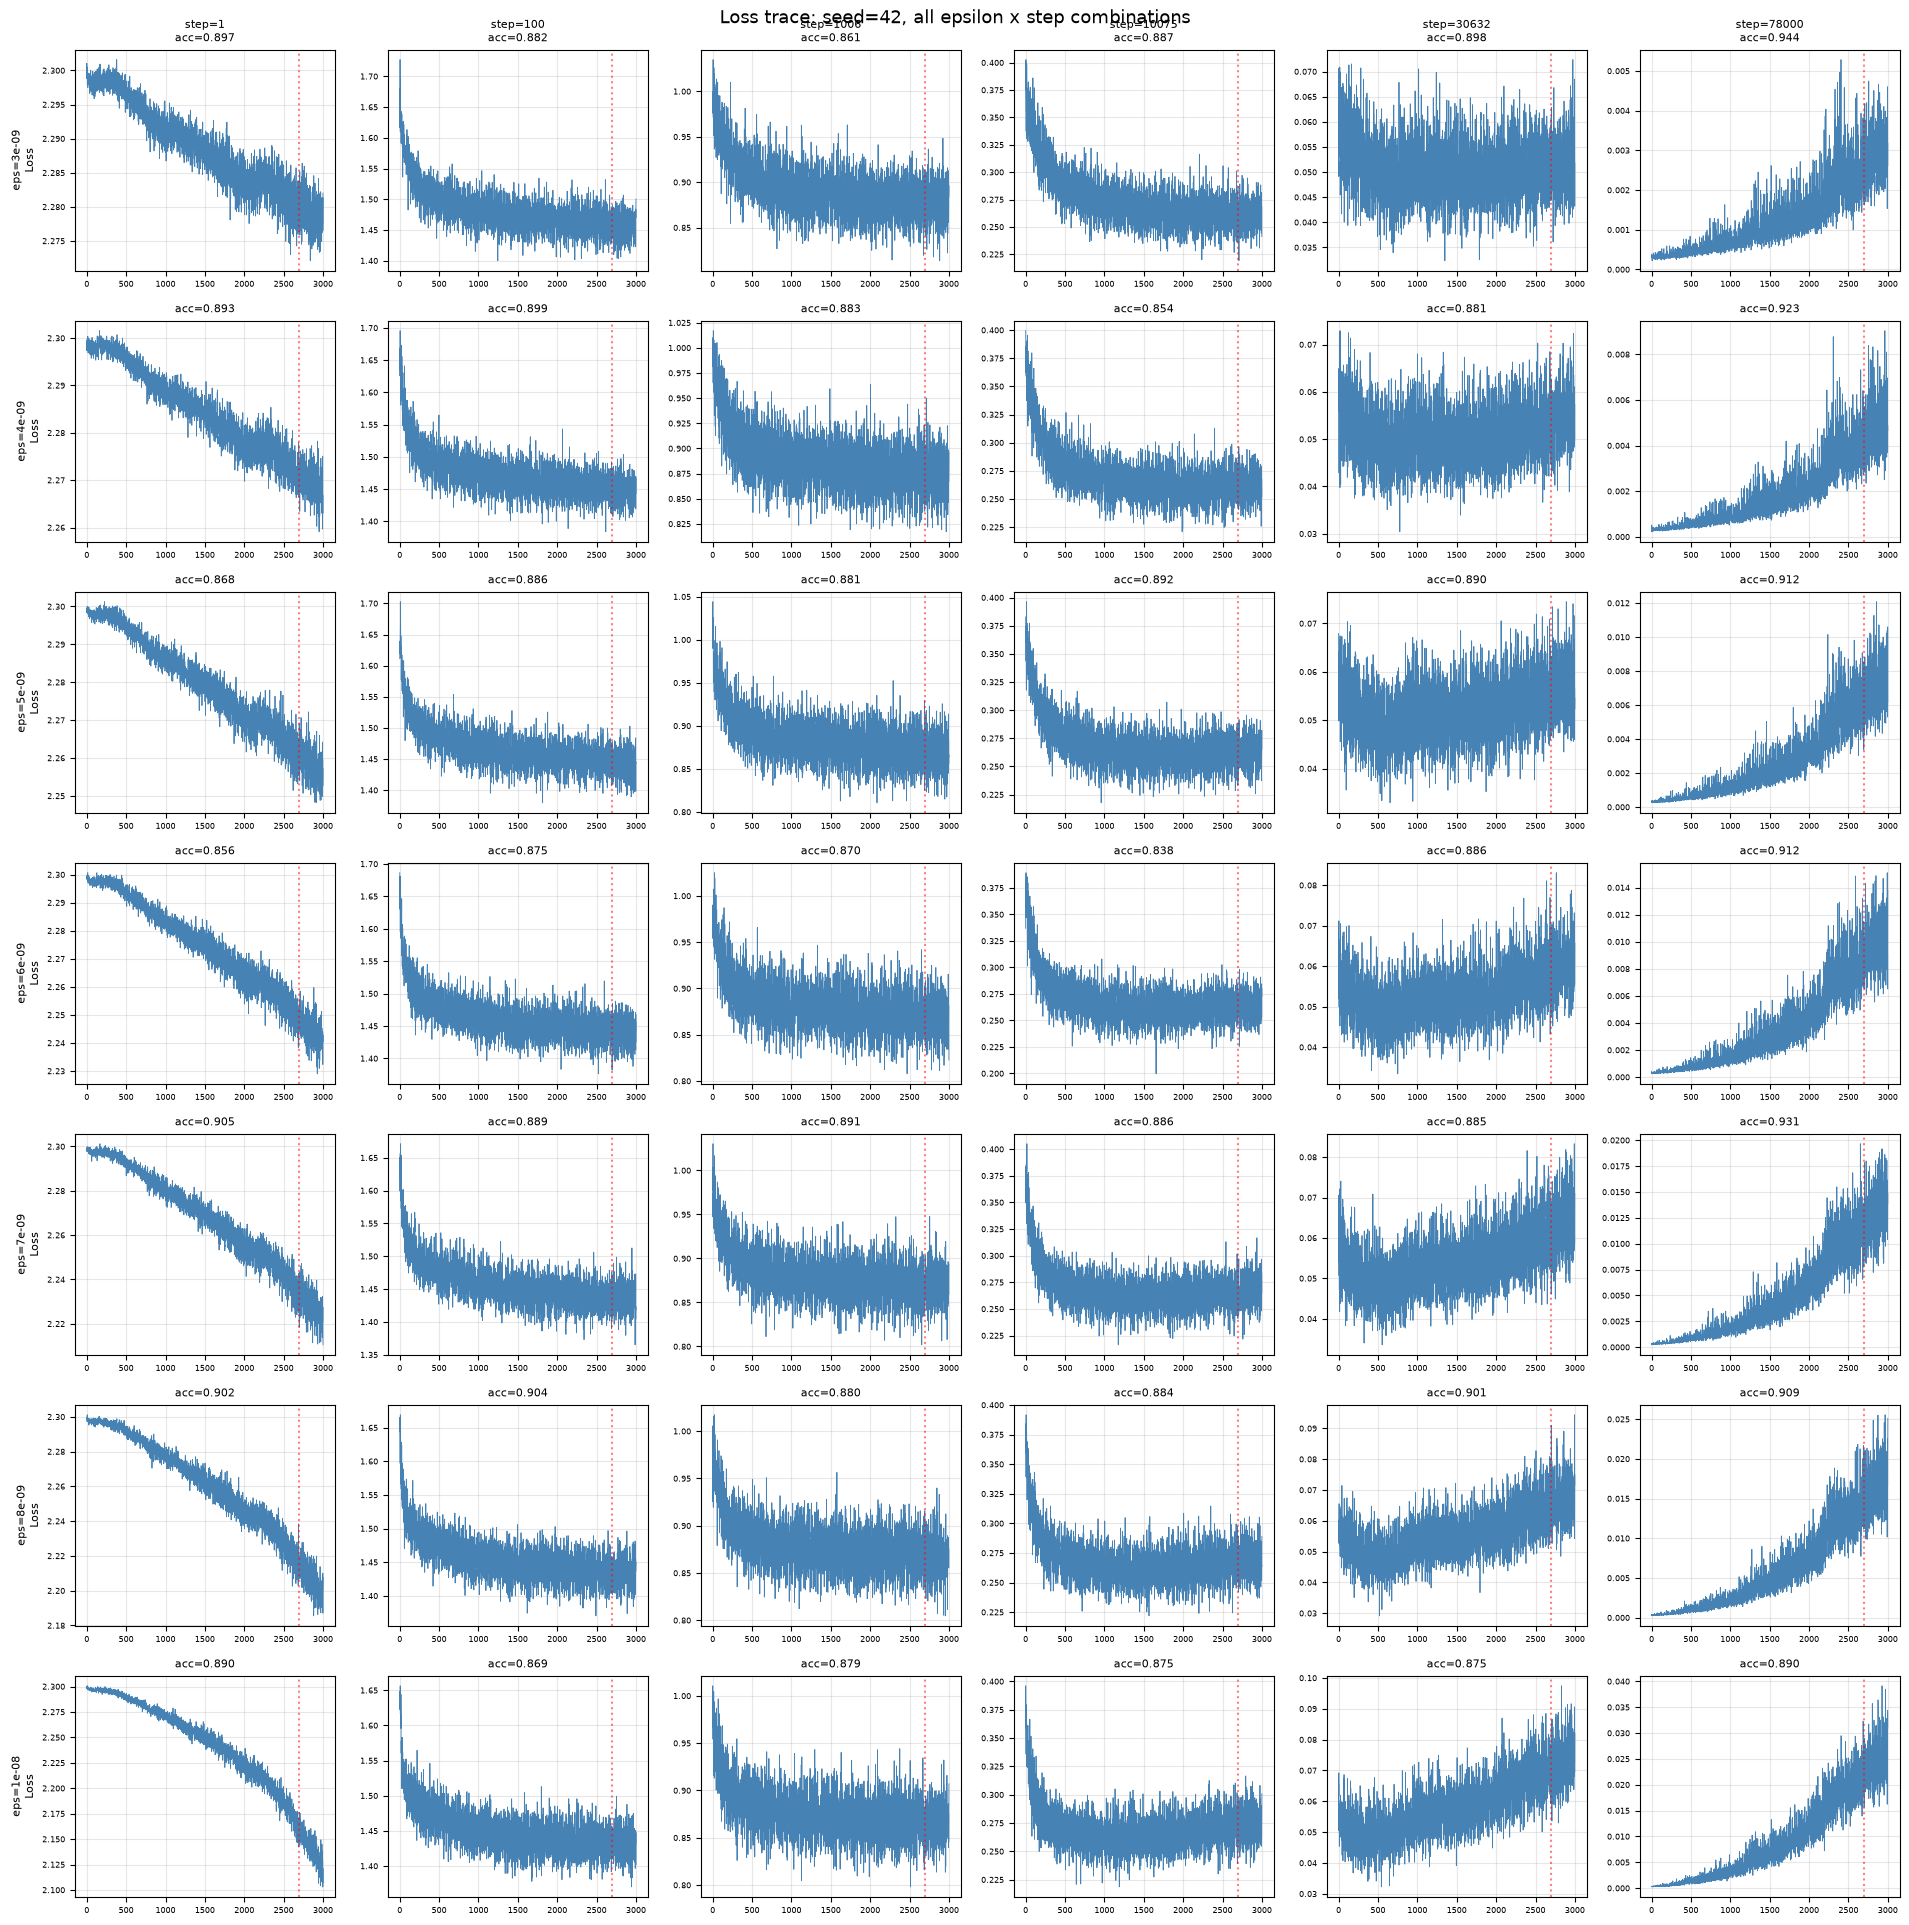

In [28]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FINE_DIR = Path("/home/nakano/server/calibration_results_dense_fine")

seed = 42
steps_all = [1, 100, 1006, 10075, 30632, 78000]
epsilons = [3e-9, 4e-9, 5e-9, 6e-9, 7e-9, 8e-9, 1e-8]

fig, axes = plt.subplots(len(epsilons), len(steps_all),
                          figsize=(3.2 * len(steps_all), 2.8 * len(epsilons)))

for row, eps in enumerate(epsilons):
    eps_str = f"eps_{eps:.0e}".replace("e-0", "e-")
    eps_dir = FINE_DIR / eps_str

    for col, step in enumerate(steps_all):
        ax = axes[row, col]

        f = eps_dir / f"calib_dense_seed{seed}_step{step}.json"
        if not f.exists():
            ax.set_title("not found", fontsize=8)
            continue

        with open(f) as fp:
            d = json.load(fp)

        r = d["results"][0]
        trace = np.array(r["loss_trace"])
        accept = r["mean_accept_prob"]

        ax.plot(trace, color="steelblue", linewidth=0.6)
        burn_in = int(len(trace) * 0.9)
        ax.axvline(burn_in, color="red", linestyle=":", alpha=0.5)

        ax.set_title(f"acc={accept:.3f}", fontsize=8)
        if row == 0:
            ax.set_title(f"step={step}\nacc={accept:.3f}", fontsize=8)
        if col == 0:
            ax.set_ylabel(f"eps={eps:.0e}\nLoss", fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.3)

fig.suptitle(f"Loss trace: seed={seed}, all epsilon x step combinations", fontsize=13)
fig.tight_layout()
plt.savefig(FINE_DIR.parent / f"loss_trace_grid_seed{seed}.pdf", bbox_inches="tight")
plt.show()

In [29]:
# %% [markdown]
# # SGLD calibration diagnostics
# gamma × epsilon グリッドの accept / flatness 可視化と loss_trace 目視確認

# %%
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

CALIB_ROOT = "/home/nakano/server/calibration_results_gamma_eps"
GAMMAS = [1.0, 3.0, 5.0, 10.0]

# %% [markdown]
# ## 1. 結果の読み込み

# %%
def load_records(root=CALIB_ROOT, gammas=GAMMAS, seed=42):
    rows = []
    for g in gammas:
        path = f"{root}/gamma_{g}/calib_seed{seed}.json"
        if not os.path.exists(path):
            print(f"[missing] {path}")
            continue
        with open(path) as f:
            d = json.load(f)
        for r in d["records"]:
            rows.append({
                "gamma": g,
                "epsilon": r["epsilon"],
                "step": r["step"],
                "accept": r["mean_accept_prob"],
                "flatness": r["flatness_score"],
                "diverged": r["diverged"],
                "llc": r.get("llc", np.nan),
                "_raw": r,
            })
    return pd.DataFrame(rows)

df = load_records()
print(f"{len(df)} records, diverged={df.diverged.sum()}")
df.sort_values(["step", "gamma", "epsilon"]).drop(columns="_raw")

# %% [markdown]
# ## 2. gamma の効果があるか — 同一 (step, eps) を gamma で横断

# %%
for metric in ["accept", "flatness"]:
    piv = df.pivot_table(index=["step", "epsilon"], columns="gamma", values=metric)
    piv["range"] = piv.max(axis=1) - piv.min(axis=1)
    piv["cv"] = piv[GAMMAS].std(axis=1) / piv[GAMMAS].abs().mean(axis=1)
    print(f"\n=== {metric}: gamma 方向の変動 ===")
    print(piv.to_string(float_format=lambda x: f"{x:.5f}"))

40 records, diverged=0

=== accept: gamma 方向の変動 ===
gamma                  1.0     3.0     5.0    10.0   range      cv
step  epsilon                                                     
19508 1.000000e-09 0.89012 0.89105 0.88342 0.89356 0.01014 0.00487
      3.000000e-09 0.86887 0.87051 0.87023 0.89331 0.02444 0.01341
      1.000000e-08 0.87816 0.87958 0.88839 0.89762 0.01947 0.01017
      3.000000e-08 0.89184 0.89378 0.87747 0.88794 0.01631 0.00819
      1.000000e-07 0.83411 0.83271 0.85102 0.85189 0.01918 0.01239
39008 1.000000e-09 0.89618 0.90402 0.90689 0.91091 0.01473 0.00688
      3.000000e-09 0.88930 0.88281 0.87806 0.88234 0.01124 0.00525
      1.000000e-08 0.85335 0.87740 0.89353 0.90164 0.04829 0.02415
      3.000000e-08 0.87435 0.90147 0.88160 0.90517 0.03082 0.01685
      1.000000e-07 0.79820 0.81098 0.78676 0.81657 0.02981 0.01662

=== flatness: gamma 方向の変動 ===
gamma                   1.0      3.0      5.0     10.0   range      cv
step  epsilon                             

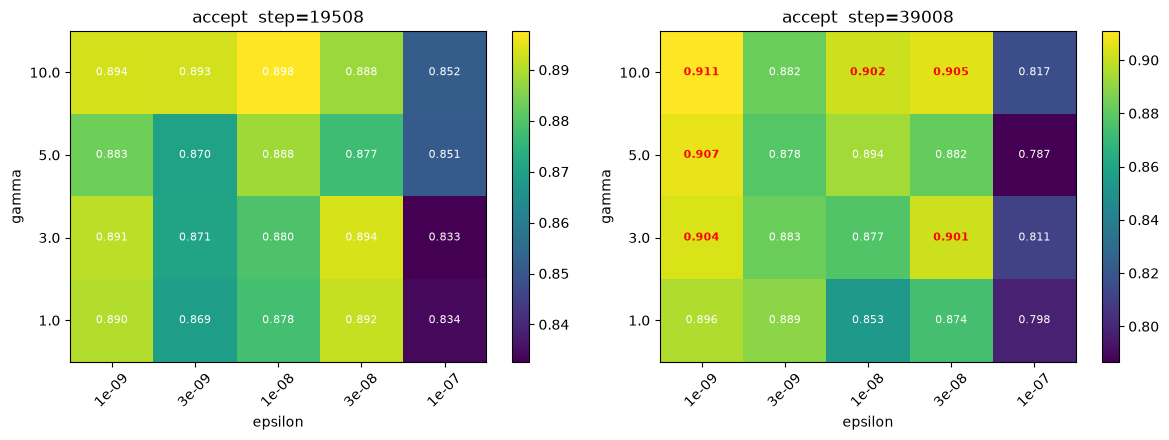

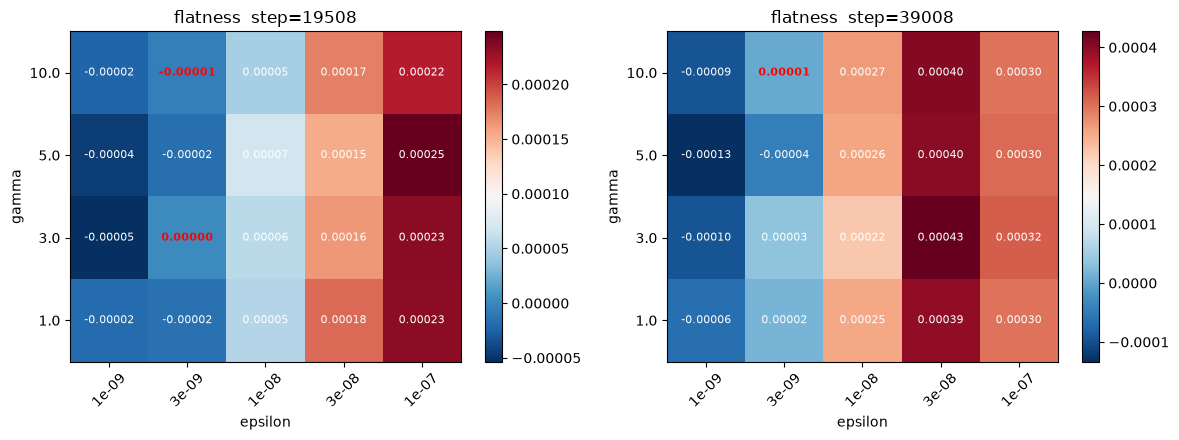

In [30]:
# %% [markdown]
# ## 3. ヒートマップ (step ごと / accept・flatness)

# %%
def heatmaps(df, metric, target=None, cmap="viridis"):
    steps = sorted(df.step.unique())
    fig, axes = plt.subplots(1, len(steps), figsize=(6*len(steps), 4.5), squeeze=False)
    for ax, s in zip(axes[0], steps):
        sub = df[df.step == s]
        piv = sub.pivot_table(index="gamma", columns="epsilon", values=metric)
        piv = piv.sort_index().sort_index(axis=1)
        im = ax.imshow(piv.values, aspect="auto", cmap=cmap, origin="lower")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels([f"{e:.0e}" for e in piv.columns], rotation=45)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels(piv.index)
        ax.set_xlabel("epsilon"); ax.set_ylabel("gamma")
        ax.set_title(f"{metric}  step={s}")
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                ok = (target[0] <= v <= target[1]) if target else False
                ax.text(j, i, f"{v:.5f}" if metric == "flatness" else f"{v:.3f}",
                        ha="center", va="center", fontsize=8,
                        color="red" if ok else "white",
                        fontweight="bold" if ok else "normal")
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

heatmaps(df, "accept", target=(0.90, 0.95))
heatmaps(df, "flatness", target=(-1e-5, 1e-5), cmap="RdBu_r")

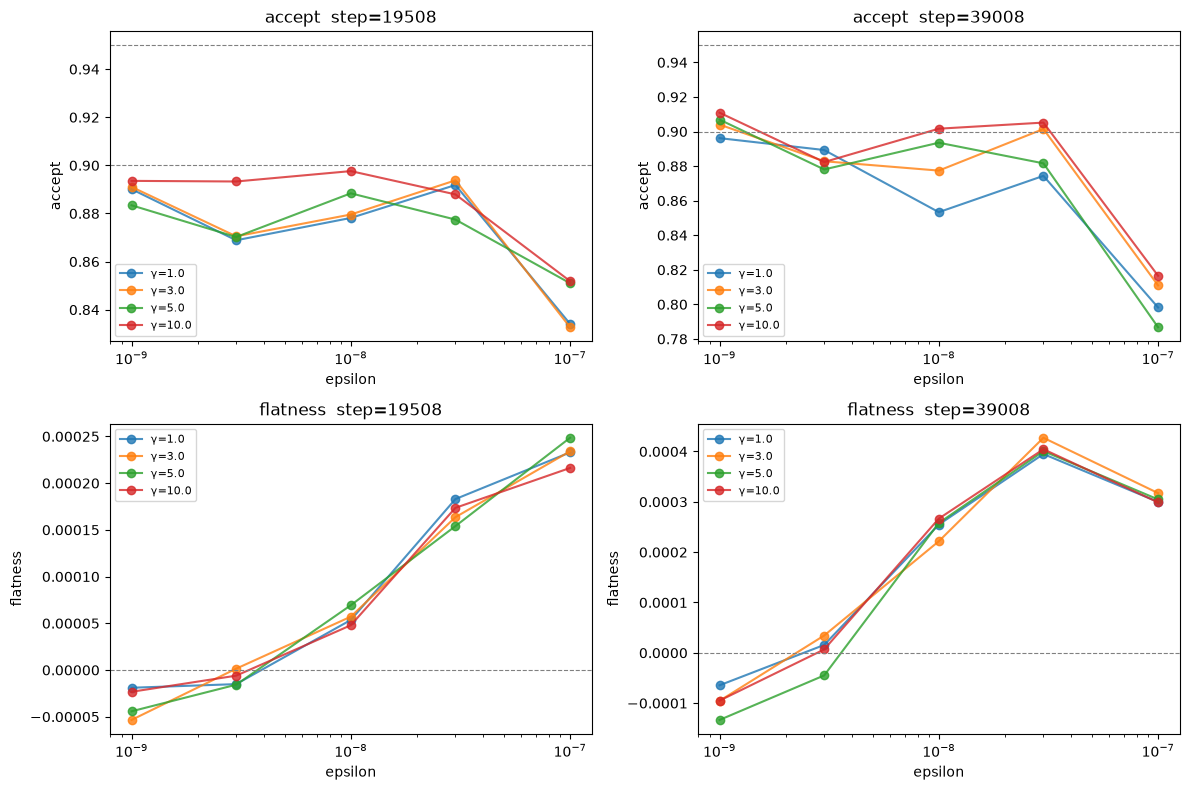

In [31]:
# %% [markdown]
# ## 4. epsilon 依存の折れ線 (gamma を重ねる)

# %%
fig, axes = plt.subplots(2, len(sorted(df.step.unique())), figsize=(12, 8), squeeze=False)
for j, s in enumerate(sorted(df.step.unique())):
    for i, (metric, hline) in enumerate([("accept", [0.90, 0.95]), ("flatness", [0.0])]):
        ax = axes[i][j]
        for g in GAMMAS:
            sub = df[(df.step == s) & (df.gamma == g)].sort_values("epsilon")
            ax.plot(sub.epsilon, sub[metric], "o-", label=f"γ={g}", alpha=0.8)
        for h in hline:
            ax.axhline(h, ls="--", c="gray", lw=0.8)
        ax.set_xscale("log"); ax.set_xlabel("epsilon"); ax.set_ylabel(metric)
        ax.set_title(f"{metric}  step={s}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

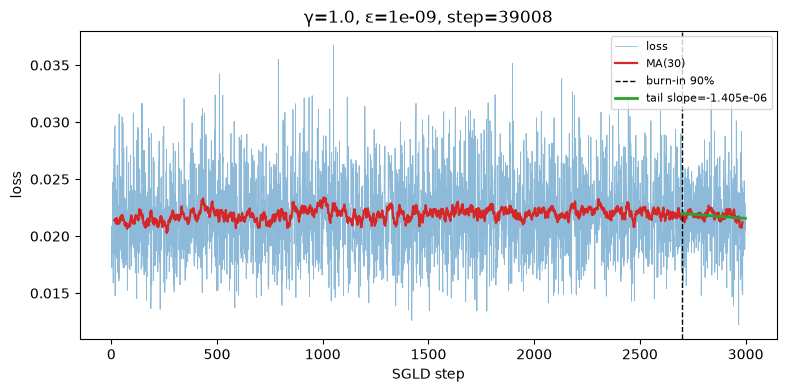

post-burnin mean=0.02177 ± 0.00316
前半/後半の平均差 = -0.00022  (定常とみなせる)
振動幅 std / ドリフト = 14.5


In [32]:
# %% [markdown]
# ## 5. loss_trace の目視確認
# JSON に loss_trace が保存されていればそれを、無ければ再実行して取得する

# %%
def get_trace(rec):
    for k in ["loss_trace", "losses", "trace"]:
        if k in rec:
            return np.asarray(rec[k], dtype=float)
    return None

def plot_trace(rec, burnin_frac=0.9, tail_frac=0.1, ax=None):
    tr = get_trace(rec)
    if tr is None:
        print("loss_trace not stored in JSON — 再実行が必要")
        return
    n = len(tr); b = int(n * burnin_frac)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr, lw=0.6, alpha=0.5, color="C0", label="loss")
    # 移動平均で振動と系統的ドリフトを分離
    w = max(1, n // 100)
    ma = np.convolve(tr, np.ones(w)/w, mode="valid")
    ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.6, color="C3", label=f"MA({w})")
    ax.axvline(b, ls="--", c="k", lw=1, label=f"burn-in {int(burnin_frac*100)}%")
    # tail の線形フィット
    t0 = int(n * (1 - tail_frac))
    x = np.arange(t0, n)
    slope, intercept = np.polyfit(x, tr[t0:], 1)
    ax.plot(x, slope*x + intercept, c="C2", lw=2,
            label=f"tail slope={slope:.3e}")
    ax.set_xlabel("SGLD step"); ax.set_ylabel("loss")
    ax.legend(fontsize=8)
    return dict(slope=slope,
                tail_mean=tr[t0:].mean(), tail_std=tr[t0:].std(),
                post_burnin_mean=tr[b:].mean(), post_burnin_std=tr[b:].std(),
                first_half_mean=tr[b:(b+n)//2].mean(),
                second_half_mean=tr[(b+n)//2:].mean())

def diagnose(rec):
    """定常性の簡易診断: 後半 burn-in を2分割して平均が一致するか"""
    st = plot_trace(rec)
    if st is None:
        return
    plt.title(f"γ={rec.get('gamma','?')}, ε={rec['epsilon']:.0e}, step={rec['step']}")
    plt.show()
    drift = st["second_half_mean"] - st["first_half_mean"]
    print(f"post-burnin mean={st['post_burnin_mean']:.5f} ± {st['post_burnin_std']:.5f}")
    print(f"前半/後半の平均差 = {drift:+.5f}  "
          f"({'定常とみなせる' if abs(drift) < st['post_burnin_std'] else '系統的ドリフトあり'})")
    print(f"振動幅 std / ドリフト = {st['post_burnin_std'] / (abs(drift)+1e-12):.1f}")

# 例: gamma=1.0, eps=3e-9, step=39008
target = df[(df.gamma == 1.0) & (np.isclose(df.epsilon, 3e-9)) & (df.step == 39008)]
if len(target):
    rec = target.iloc[0]["_raw"]; rec["gamma"] = 1.0
    diagnose(rec)

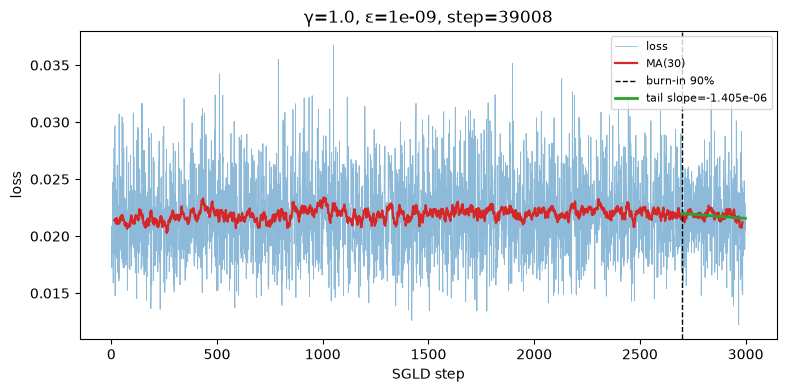

post-burnin mean=0.02177 ± 0.00316
前半/後半の平均差 = -0.00022  (定常とみなせる)
振動幅 std / ドリフト = 14.5


In [33]:
# %% [markdown]
# ## 5. loss_trace の目視確認
# JSON に loss_trace が保存されていればそれを、無ければ再実行して取得する

# %%
def get_trace(rec):
    for k in ["loss_trace", "losses", "trace"]:
        if k in rec:
            return np.asarray(rec[k], dtype=float)
    return None

def plot_trace(rec, burnin_frac=0.9, tail_frac=0.1, ax=None):
    tr = get_trace(rec)
    if tr is None:
        print("loss_trace not stored in JSON — 再実行が必要")
        return
    n = len(tr); b = int(n * burnin_frac)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr, lw=0.6, alpha=0.5, color="C0", label="loss")
    # 移動平均で振動と系統的ドリフトを分離
    w = max(1, n // 100)
    ma = np.convolve(tr, np.ones(w)/w, mode="valid")
    ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.6, color="C3", label=f"MA({w})")
    ax.axvline(b, ls="--", c="k", lw=1, label=f"burn-in {int(burnin_frac*100)}%")
    # tail の線形フィット
    t0 = int(n * (1 - tail_frac))
    x = np.arange(t0, n)
    slope, intercept = np.polyfit(x, tr[t0:], 1)
    ax.plot(x, slope*x + intercept, c="C2", lw=2,
            label=f"tail slope={slope:.3e}")
    ax.set_xlabel("SGLD step"); ax.set_ylabel("loss")
    ax.legend(fontsize=8)
    return dict(slope=slope,
                tail_mean=tr[t0:].mean(), tail_std=tr[t0:].std(),
                post_burnin_mean=tr[b:].mean(), post_burnin_std=tr[b:].std(),
                first_half_mean=tr[b:(b+n)//2].mean(),
                second_half_mean=tr[(b+n)//2:].mean())

def diagnose(rec):
    """定常性の簡易診断: 後半 burn-in を2分割して平均が一致するか"""
    st = plot_trace(rec)
    if st is None:
        return
    plt.title(f"γ={rec.get('gamma','?')}, ε={rec['epsilon']:.0e}, step={rec['step']}")
    plt.show()
    drift = st["second_half_mean"] - st["first_half_mean"]
    print(f"post-burnin mean={st['post_burnin_mean']:.5f} ± {st['post_burnin_std']:.5f}")
    print(f"前半/後半の平均差 = {drift:+.5f}  "
          f"({'定常とみなせる' if abs(drift) < st['post_burnin_std'] else '系統的ドリフトあり'})")
    print(f"振動幅 std / ドリフト = {st['post_burnin_std'] / (abs(drift)+1e-12):.1f}")

# 例: gamma=1.0, eps=3e-9, step=39008
target = df[(df.gamma == 1.0) & (np.isclose(df.epsilon, 3e-9)) & (df.step == 39008)]
if len(target):
    rec = target.iloc[0]["_raw"]; rec["gamma"] = 1.0
    diagnose(rec)

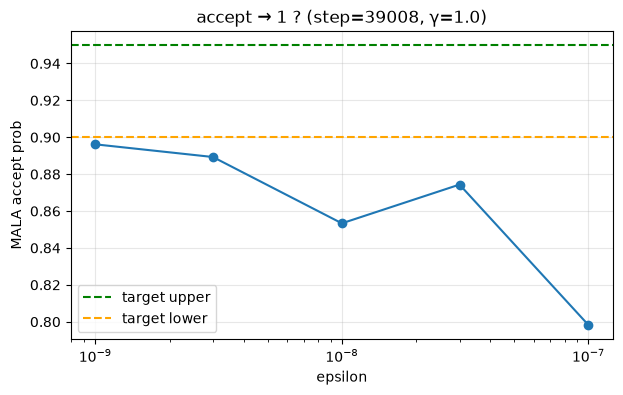

     epsilon   accept
1.000000e-09 0.896177
3.000000e-09 0.889302
1.000000e-08 0.853352
3.000000e-08 0.874354
1.000000e-07 0.798202

判定: eps を下げても accept が頭打ちなら MALA 実装側の系統誤差を疑う


In [34]:
# %% [markdown]
# ## 6. epsilon 極小域の追加スキャン (accept の頭打ち検証)
# 別セッションで calibrate_gamma_epsilon_dense.py を eps=1e-10, 1e-11 で回した結果を読む

# %%
def accept_vs_eps_asymptote(df_all, step, gamma=1.0):
    sub = df_all[(df_all.step == step) & (df_all.gamma == gamma)].sort_values("epsilon")
    plt.figure(figsize=(7, 4))
    plt.semilogx(sub.epsilon, sub.accept, "o-")
    plt.axhline(0.95, ls="--", c="g", label="target upper")
    plt.axhline(0.90, ls="--", c="orange", label="target lower")
    plt.xlabel("epsilon"); plt.ylabel("MALA accept prob")
    plt.title(f"accept → 1 ? (step={step}, γ={gamma})")
    plt.legend(); plt.grid(alpha=0.3); plt.show()
    print(sub[["epsilon", "accept"]].to_string(index=False))
    print("\n判定: eps を下げても accept が頭打ちなら MALA 実装側の系統誤差を疑う")

accept_vs_eps_asymptote(df, step=39008)

<class 'list'> 200
step=39008 ≒ epoch 100.0
epoch=100: train_loss=0.05382
SGLD trace level ≈ 0.021
差 = 0.03282  (乖離あり → chainは探索できている)


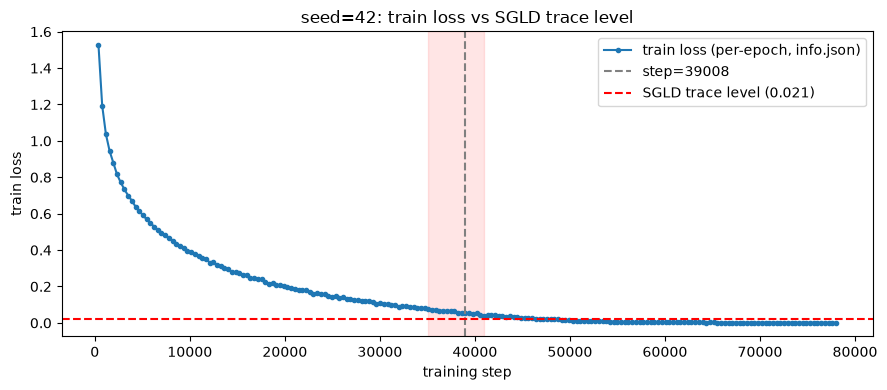

In [35]:
# %% [markdown]
# # train loss (info.json) と SGLD trace レベルの比較
# 目的: step=39008 の trace loss (~0.021) が既に収束済みの train loss と一致するか確認

# %%
import json
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
STEP_OF_INTEREST = 39008
STEPS_PER_EPOCH = 78000 // 200  # = 390

with open(f'/home/nakano/server/dsb_dense_logs/seed{SEED}_info.json') as f:
    info = json.load(f)

print(type(info), list(info.keys()) if isinstance(info, dict) else len(info))

# %%
# --- 構造に応じて調整。よくある2パターンを両方試す ---
def extract_series(info, key_candidates=("train_loss", "loss", "train")):
    if isinstance(info, dict):
        for k in key_candidates:
            if k in info:
                return np.asarray(info[k], dtype=float)
        # ネストしている場合 (例: info["history"]["train_loss"])
        for v in info.values():
            if isinstance(v, dict):
                for k in key_candidates:
                    if k in v:
                        return np.asarray(v[k], dtype=float)
    elif isinstance(info, list):
        # エポックごとのdictのリストの場合
        for k in key_candidates:
            if k in info[0]:
                return np.asarray([e[k] for e in info], dtype=float)
    raise KeyError(f"train loss series not found, keys tried: {key_candidates}")

train_loss = extract_series(info)
epochs = np.arange(1, len(train_loss) + 1)
steps = epochs * STEPS_PER_EPOCH

# %%
target_epoch = STEP_OF_INTEREST / STEPS_PER_EPOCH
print(f"step={STEP_OF_INTEREST} ≒ epoch {target_epoch:.1f}")

# 最も近いepochのtrain lossを取得
idx = np.argmin(np.abs(epochs - target_epoch))
print(f"epoch={epochs[idx]}: train_loss={train_loss[idx]:.5f}")

TRACE_LEVEL = 0.021  # Image 4 から読み取った値
print(f"SGLD trace level ≈ {TRACE_LEVEL}")
print(f"差 = {abs(train_loss[idx] - TRACE_LEVEL):.5f}  "
      f"({'ほぼ一致 → chainが動いていない可能性' if abs(train_loss[idx]-TRACE_LEVEL) < 0.005 else '乖離あり → chainは探索できている'})")

# %%
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, train_loss, "o-", ms=3, label="train loss (per-epoch, info.json)")
ax.axvline(STEP_OF_INTEREST, ls="--", c="gray", label=f"step={STEP_OF_INTEREST}")
ax.axhline(TRACE_LEVEL, ls="--", c="red", label=f"SGLD trace level ({TRACE_LEVEL})")
ax.axvspan(STEP_OF_INTEREST*0.9, STEP_OF_INTEREST*1.05, alpha=0.1, color="red")
ax.set_xlabel("training step"); ax.set_ylabel("train loss")
ax.legend(); ax.set_title(f"seed={SEED}: train loss vs SGLD trace level")
plt.tight_layout(); plt.show()

# TEMP

In [36]:
# %% [markdown]
# # loss_trace 目視確認 — 新代表点 step=60272

# %%
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CALIB_DIR = "/home/nakano/server/calibration_results_gamma_eps/verify_fix"
LABELS = ["seed42_newrepr_1e-9", "seed42_newrepr_3e-9", "seed42_newrepr_1e-8"]

# %%
def load_record(label, calib_dir=CALIB_DIR):
    path = f"{calib_dir}/calib_{label}.json"
    with open(path) as f:
        d = json.load(f)
    assert len(d["records"]) == 1, f"expected 1 record, got {len(d['records'])}"
    return d["records"][0]

records = {lbl: load_record(lbl) for lbl in LABELS}
print(f"loaded {len(records)} records")

# %%
def compute_trace_stats(rec, burnin_frac=0.9, tail_frac=0.1):
    tr = np.asarray(rec["loss_trace"], dtype=float)
    n = len(tr)
    b = int(n * burnin_frac)

    t0 = int(n * (1 - tail_frac))
    x = np.arange(t0, n)
    slope, _ = np.polyfit(x, tr[t0:], 1)

    post_burnin = tr[b:]
    half = (b + n) // 2
    first_half_mean = tr[b:half].mean()
    second_half_mean = tr[half:].mean()
    drift = second_half_mean - first_half_mean
    post_burnin_std = post_burnin.std()
    stationary = abs(drift) < post_burnin_std

    return dict(
        trace=tr, burnin_idx=b, tail_start=t0, tail_slope=slope,
        post_burnin_mean=post_burnin.mean(), post_burnin_std=post_burnin_std,
        drift=drift, stationary=stationary,
        drift_over_std=abs(drift) / (post_burnin_std + 1e-12),
    )

stats = {lbl: compute_trace_stats(records[lbl]) for lbl in LABELS}
print("stats computed")

loaded 3 records
stats computed


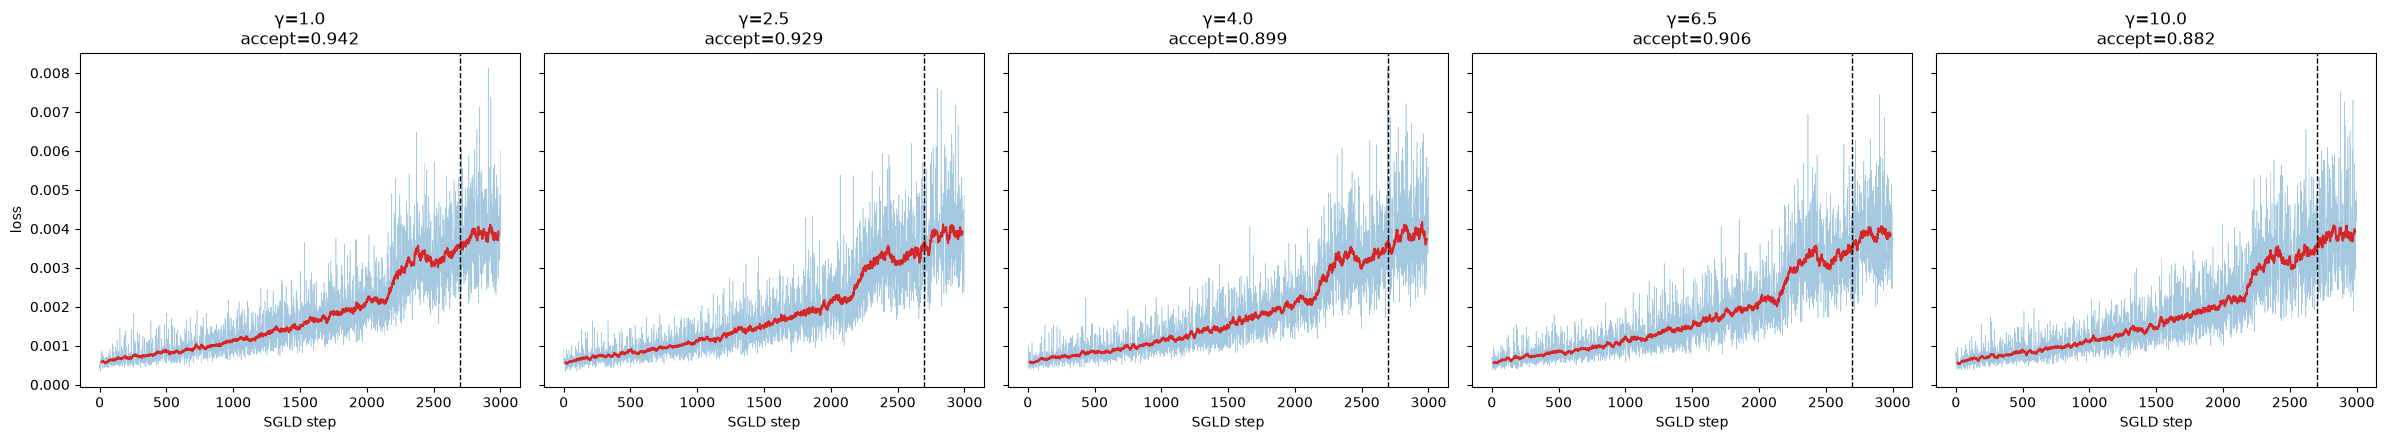

 gamma   accept   flat_score  post_burnin_start  post_burnin_end rise_ratio
   1.0    0.942      0.00024            0.00362          0.00386       1.07
   2.5    0.929      0.00028            0.00362          0.00385       1.06
   4.0    0.899      0.00031            0.00362          0.00388       1.07
   6.5    0.906      0.00018            0.00370          0.00392       1.06
  10.0    0.882      0.00019            0.00371          0.00387       1.04


In [37]:
import json
import numpy as np
import matplotlib.pyplot as plt

CALIB_DIR = "/home/nakano/server/calibration_results_gamma_eps/verify_fix"
GAMMAS = [1.0, 2.5, 4.0, 6.5, 10.0]

records = {}
for g in GAMMAS:
    with open(f"{CALIB_DIR}/calib_seed42_gcheck_{g}.json") as f:
        d = json.load(f)
    records[g] = d["records"][0]

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)
for ax, g in zip(axes, GAMMAS):
    r = records[g]
    tr = np.array(r["loss_trace"])
    n = len(tr)
    b = int(n * 0.9)

    ax.plot(tr, lw=0.4, alpha=0.4, color="C0")
    w = max(1, n // 100)
    ma = np.convolve(tr, np.ones(w)/w, mode="valid")
    ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.5, color="C3")
    ax.axvline(b, ls="--", c="k", lw=1)
    ax.set_title(f"γ={g}\naccept={r['mean_accept_prob']:.3f}")
    ax.set_xlabel("SGLD step")
axes[0].set_ylabel("loss")
plt.tight_layout()
plt.show()

# burn-in後の上昇の度合いを定量化
print(f"{'gamma':>6} {'accept':>8} {'flat_score':>12} {'post_burnin_start':>18} {'post_burnin_end':>16} {'rise_ratio':>10}")
for g in GAMMAS:
    r = records[g]
    tr = np.array(r["loss_trace"])
    n = len(tr)
    b = int(n * 0.9)
    post = tr[b:]
    start_val = post[:len(post)//4].mean()
    end_val = post[-len(post)//4:].mean()
    rise_ratio = end_val / (start_val + 1e-12)
    print(f"{g:>6} {r['mean_accept_prob']:>8.3f} {r['flatness_score']:>12.5f} "
          f"{start_val:>18.5f} {end_val:>16.5f} {rise_ratio:>10.2f}")

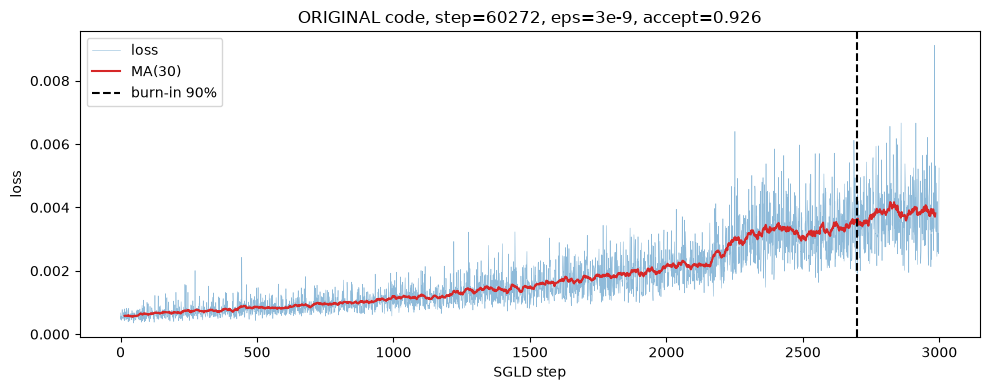

accept=0.926, flat_score=0.00022
burn-in後を4分割した平均: ['0.00362', '0.00396', '0.00382', '0.00384']


In [38]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_original_recheck.json") as f:
    d = json.load(f)
rec = d["records"][0]
tr = np.array(rec["loss_trace"])
n = len(tr)
b = int(n * 0.9)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr, lw=0.4, alpha=0.5, color="C0", label="loss")
w = max(1, n // 100)
ma = np.convolve(tr, np.ones(w)/w, mode="valid")
ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.5, color="C3", label=f"MA({w})")
ax.axvline(b, ls="--", c="k", label="burn-in 90%")
ax.set_title(f"ORIGINAL code, step=60272, eps=3e-9, accept={rec['mean_accept_prob']:.3f}")
ax.set_xlabel("SGLD step"); ax.set_ylabel("loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"accept={rec['mean_accept_prob']:.3f}, flat_score={rec['flatness_score']:.5f}")
quarters = np.array_split(tr[b:], 4)
q_means = [q.mean() for q in quarters]
print("burn-in後を4分割した平均:", [f"{m:.5f}" for m in q_means])

In [39]:
quarters = np.array_split(tr[b:], 4)
q_means = [q.mean() for q in quarters]
print("burn-in後(300ステップ)を4分割した平均:", [f"{m:.5f}" for m in q_means])
print("最初と最後の差:", q_means[-1] - q_means[0])
print("差 / 全体std:", (q_means[-1] - q_means[0]) / tr[b:].std())

burn-in後(300ステップ)を4分割した平均: ['0.00362', '0.00396', '0.00382', '0.00384']
最初と最後の差: 0.00021767726168036476
差 / 全体std: 0.22253082094350285


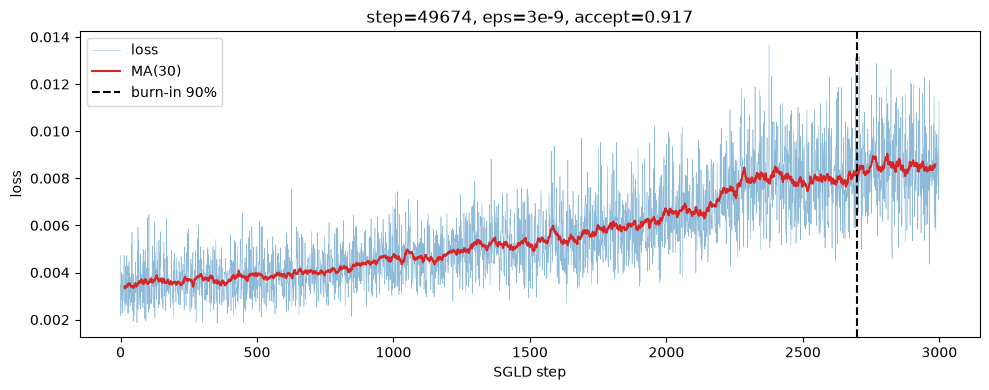

accept=0.917, flat_score=-0.00000
burn-in後を4分割した平均: ['0.00850', '0.00859', '0.00844', '0.00849']
最初と最後の差: -6.640224407116618e-06
差 / 全体std: -0.004117962109739243
trace全体の最小値: 0.00185, 最大値: 0.01366, 比率: 7.37


In [40]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_earlyrepr_49674.json") as f:
    d = json.load(f)
rec = d["records"][0]
tr = np.array(rec["loss_trace"])
n = len(tr)
b = int(n * 0.9)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr, lw=0.4, alpha=0.5, color="C0", label="loss")
w = max(1, n // 100)
ma = np.convolve(tr, np.ones(w)/w, mode="valid")
ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.5, color="C3", label=f"MA({w})")
ax.axvline(b, ls="--", c="k", label="burn-in 90%")
ax.set_title(f"step=49674, eps=3e-9, accept={rec['mean_accept_prob']:.3f}")
ax.set_xlabel("SGLD step"); ax.set_ylabel("loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"accept={rec['mean_accept_prob']:.3f}, flat_score={rec['flatness_score']:.5f}")
quarters = np.array_split(tr[b:], 4)
q_means = [q.mean() for q in quarters]
print("burn-in後を4分割した平均:", [f"{m:.5f}" for m in q_means])
drift = q_means[-1] - q_means[0]
print("最初と最後の差:", drift)
print("差 / 全体std:", drift / tr[b:].std())


print(f"trace全体の最小値: {tr.min():.5f}, 最大値: {tr.max():.5f}, 比率: {tr.max()/tr.min():.2f}")

# Grid Saerch of Callibration of the LLC hypara

step=49674: burn-in後4分割平均=['0.00636', '0.00649', '0.00633', '0.00638'], drift/std=0.0101
step=60272: burn-in後4分割平均=['0.00225', '0.00234', '0.00230', '0.00230'], drift/std=0.0850


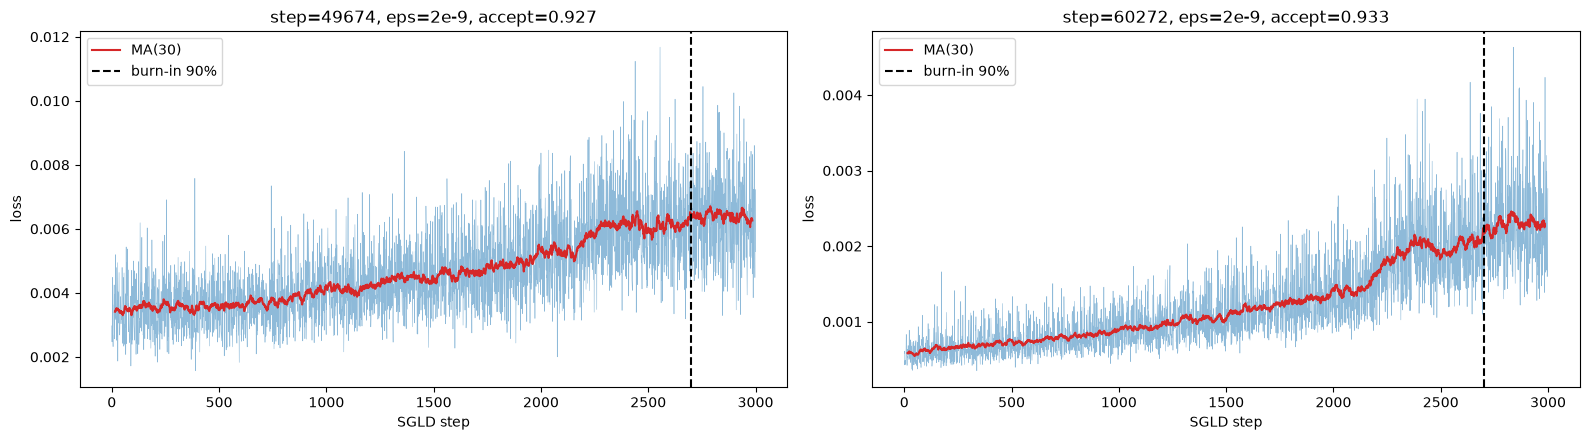

In [41]:
import json
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

for ax, step in zip(axes, [49674, 60272]):
    with open(f"/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_finalgrid_s{step}.json") as f:
        d = json.load(f)
    rec = next(r for r in d["records"] if abs(r["epsilon"] - 2e-9) < 1e-15)
    tr = np.array(rec["loss_trace"])
    n = len(tr)
    b = int(n * 0.9)

    ax.plot(tr, lw=0.4, alpha=0.5, color="C0")
    w = max(1, n // 100)
    ma = np.convolve(tr, np.ones(w)/w, mode="valid")
    ax.plot(np.arange(len(ma)) + w//2, ma, lw=1.5, color="C3", label="MA(30)")
    ax.axvline(b, ls="--", c="k", label="burn-in 90%")
    ax.set_title(f"step={step}, eps=2e-9, accept={rec['mean_accept_prob']:.3f}")
    ax.set_xlabel("SGLD step"); ax.set_ylabel("loss")
    ax.legend()

    quarters = np.array_split(tr[b:], 4)
    q_means = [q.mean() for q in quarters]
    drift = q_means[-1] - q_means[0]
    print(f"step={step}: burn-in後4分割平均={[f'{m:.5f}' for m in q_means]}, "
          f"drift/std={drift/tr[b:].std():.4f}")

plt.tight_layout()
plt.show()

accept=0.432, flat_score=0.00381
init_loss周辺との比較のため、trace先頭・末尾を確認:
trace[0:5] = [0.00042801 0.00060287 0.00068663 0.00041844 0.0008104 ]
trace[-5:] = [1.57791290e+01 3.52408371e+01 4.99656445e+03 1.16671000e+17
            nan]
post_burnin_mean = nan, std = nan
burn-in後10分割平均: ['1.39768', '1.41092', '1.42268', '1.40183', '1.41283', '1.38447', '1.42842', '1.40800', '1.44010', 'nan']


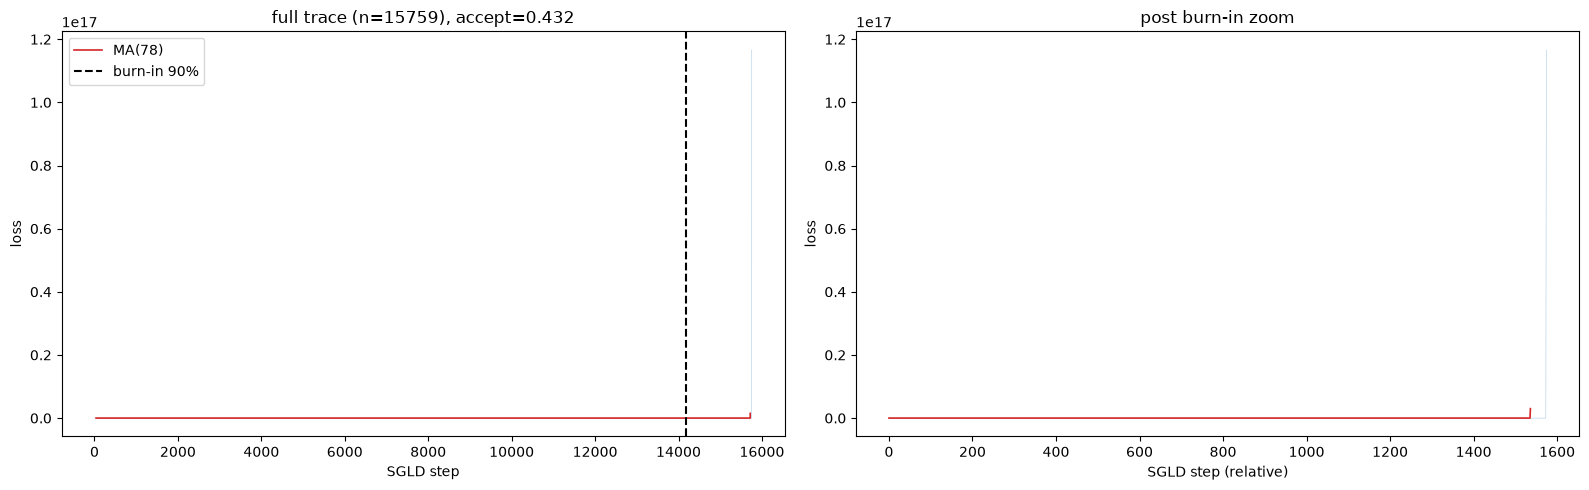

In [42]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_paperlong.json") as f:
    d = json.load(f)

rec = d["records"][0]
tr = np.array(rec["loss_trace"])
n = len(tr)
b = int(n * 0.9)

print(f"accept={rec['mean_accept_prob']:.3f}, flat_score={rec['flatness_score']:.5f}")
print(f"init_loss周辺との比較のため、trace先頭・末尾を確認:")
print(f"trace[0:5] = {tr[:5]}")
print(f"trace[-5:] = {tr[-5:]}")
print(f"post_burnin_mean = {tr[b:].mean():.5f}, std = {tr[b:].std():.5f}")

# burn-in後をさらに複数分割してdriftを見る
n_div = 10
quarters = np.array_split(tr[b:], n_div)
q_means = [q.mean() for q in quarters]
print(f"burn-in後{n_div}分割平均: {[f'{m:.5f}' for m in q_means]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(tr, lw=0.3, alpha=0.5, color="C0")
w = max(1, n // 200)
ma = np.convolve(tr, np.ones(w)/w, mode="valid")
axes[0].plot(np.arange(len(ma)) + w//2, ma, lw=1.2, color="C3", label=f"MA({w})")
axes[0].axvline(b, ls="--", c="k", label="burn-in 90%")
axes[0].set_title(f"full trace (n={n}), accept={rec['mean_accept_prob']:.3f}")
axes[0].set_xlabel("SGLD step"); axes[0].set_ylabel("loss")
axes[0].legend()

# burn-in後だけ拡大
axes[1].plot(tr[b:], lw=0.3, alpha=0.5, color="C0")
ma2 = np.convolve(tr[b:], np.ones(w//2)/max(1,w//2), mode="valid")
axes[1].plot(ma2, lw=1.2, color="C3")
axes[1].set_title("post burn-in zoom")
axes[1].set_xlabel("SGLD step (relative)"); axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()